In [1]:
#!pip install torch
import torch
import matplotlib.pyplot as plt
import numpy as np
import torch.nn as nn
import torch.nn.functional as F

## Autograd

In [2]:
x = torch.tensor(1.0, requires_grad=True)
y = torch.tensor(2.0, requires_grad=True)
z = torch.tensor(3.0, requires_grad=True)

f = x**2 + y**2 + z**2

f.backward()

print("Gradiente de f con respecto a x:", x.grad.item())
print("Gradiente de f con respecto a y:", y.grad.item())
print("Gradiente de f con respecto a z:", z.grad.item())

Gradiente de f con respecto a x: 2.0
Gradiente de f con respecto a y: 4.0
Gradiente de f con respecto a z: 6.0


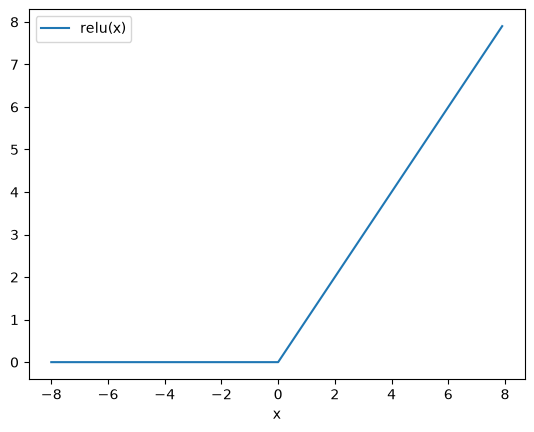

In [3]:
x = torch.arange(-8.0, 8.0, 0.1, requires_grad=True)
y = torch.relu(x)

plt.plot(x.detach(), y.detach(),label='relu(x)')
plt.xlabel('x')
plt.legend()
plt.show()

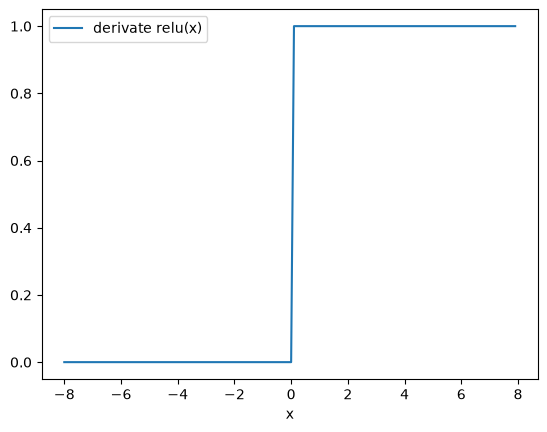

In [4]:
y.backward(torch.ones_like(x), retain_graph=True)

plt.plot(x.detach(), x.grad,label='derivate relu(x)')

plt.xlabel('x')
plt.legend()
plt.show()

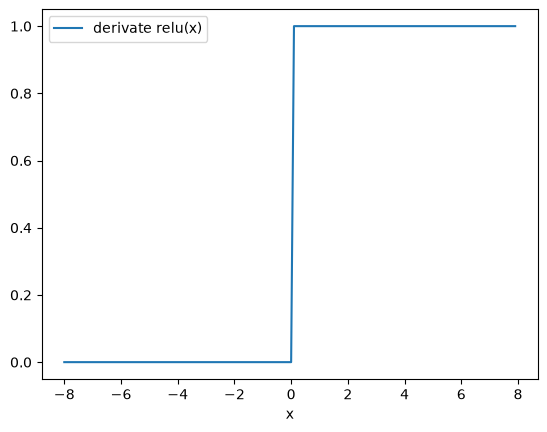

In [5]:
x.grad.data.zero_()
y.backward(torch.ones_like(x), retain_graph=True)

plt.plot(x.detach(), x.grad,label='derivate relu(x)')

plt.xlabel('x')
plt.legend()
plt.show()

Calcular numéricamente la derivada de la función sigmoide (`torch.sigmoid(x)`)
$$\operatorname{sigmoid}(x) = \frac{1}{1 + \exp(-x)}.$$
y compararla con la expresión analítica

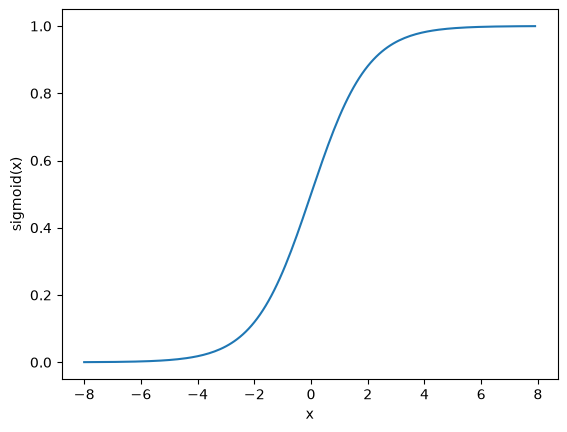

In [6]:
y = torch.sigmoid(x)
plt.plot(x.detach(), y.detach())
plt.xlabel('x')
plt.ylabel('sigmoid(x)')
plt.show()

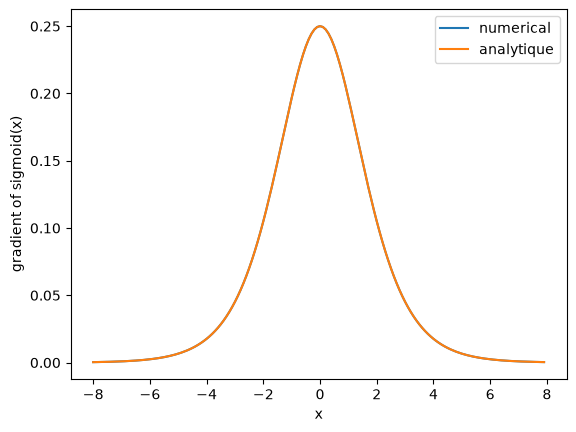

In [7]:
x.grad.data.zero_()
y.backward(torch.ones_like(x), retain_graph=True)

plt.plot(x.detach(), x.grad,label='numerical')

plt.plot(x.detach(),torch.sigmoid(x).detach()*(1-torch.sigmoid(x)).detach(),label='analytique')
plt.ylabel('gradient of sigmoid(x)')
plt.xlabel('x')
plt.legend()
plt.show()

# Conjunto de datos no linealmente separables

Creamos un conjunto de datos con 4 clases que no pueden separarse linealmente



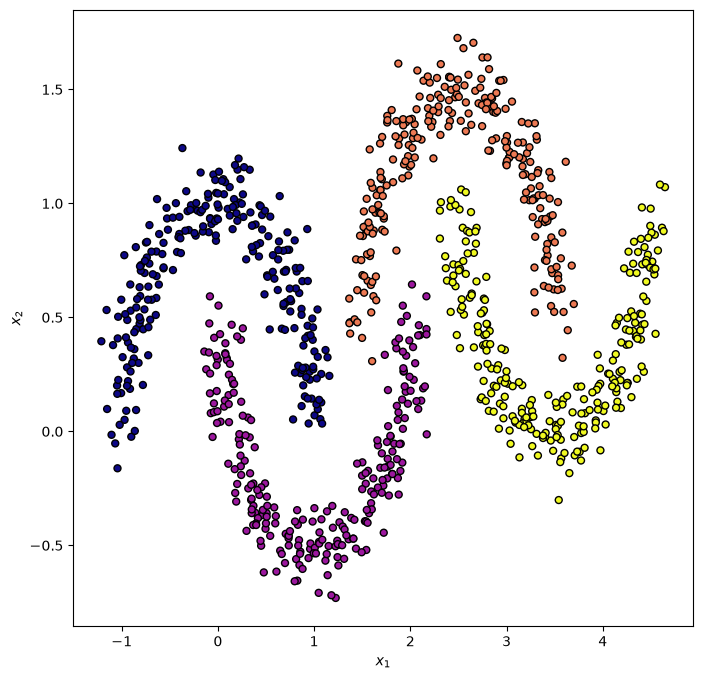

In [8]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

X, y = make_moons(n_samples=500, noise=0.1, random_state=42)
X2, y2 = make_moons(n_samples=500, noise=0.1, random_state=0)

X=torch.tensor(X)
X2=torch.tensor(X2)
y=torch.tensor(y)
y2=torch.tensor(y2)

X=torch.concat((X,X2+torch.tensor((2.5,0.5))),dim=0)
yc=torch.concat((y,y2+2),dim=0)

plt.figure(figsize=(8, 8))
plt.scatter(X[:, 0], X[:, 1], c=yc, cmap=plt.cm.plasma, edgecolor='k', s=25)
plt.xlabel("$x_1$")
plt.ylabel("$x_2$")
plt.show()

num_classes=4

X=X.float()
y=F.one_hot(yc, num_classes=num_classes)

A continuación definimos los parámetros y las funciones, actualizamos los parámetros y comenzamos el proceso de entrenamiento

In [10]:
import torch
import torch.nn as nn

def init_model(num_inputs, num_outputs):
    W1 = nn.Parameter(torch.randn(num_inputs, num_outputs) * 0.1)
    b1 = nn.Parameter(torch.zeros(num_outputs))
    return [W1, b1]


def forward(X, W1, b1):
    O = torch.matmul(X, W1) + b1
    return torch.softmax(O, dim=1)


def predict(X, W1, b1):
    O = torch.matmul(X, W1) + b1
    return torch.argmax(O, dim=1)


def cross_entropy_loss(X, labels, W1, b1):
    y_pred = forward(X, W1, b1)
    return -torch.sum(labels * torch.log(y_pred + 1e-8)) / X.size(0)


def errors(X, labels, W1, b1):
    class_pred = predict(X, W1, b1)
    class_original = torch.argmax(labels, dim=1)
    return torch.sum(class_pred != class_original) / X.shape[0]


def param_update(params, lr):
    with torch.no_grad():
        for p in params:
            if p.grad is not None:
                p.data -= lr * p.grad


def train_step(X, labels, params, lr):
    
    W1, b1 = params

    loss = cross_entropy_loss(X, labels, W1, b1)

    for p in params:
        p.grad = None

    loss.backward()

    param_update(params, lr)

    err = errors(X, labels, W1, b1)

    return loss.item(), err.item()


Ahora entrenamos el perceptrón multiclase para distinguir las 4 clases.

In [11]:
num_classes = 4

params = init_model(num_inputs=X.shape[1], num_outputs=num_classes)

learning_rate = 0.5
epochs = 1000



for epoch in range(epochs):
    
    loss, err = train_step(X, y, params, learning_rate)
    
    #print(f"Epoch {epoch+1}, Loss: {loss}, Error: {err}")

    if err == 0:
        break


Si intentamos trazar directamente las fronteras del perceptron se observa que no son del todo correctas.

C:\Users\elena\AppData\Local\Temp\ipykernel_400\2303842260.py:9: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
C:\Users\elena\AppData\Local\Temp\ipykernel_400\2303842260.py:10: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.arange(y_min, y_max, h))


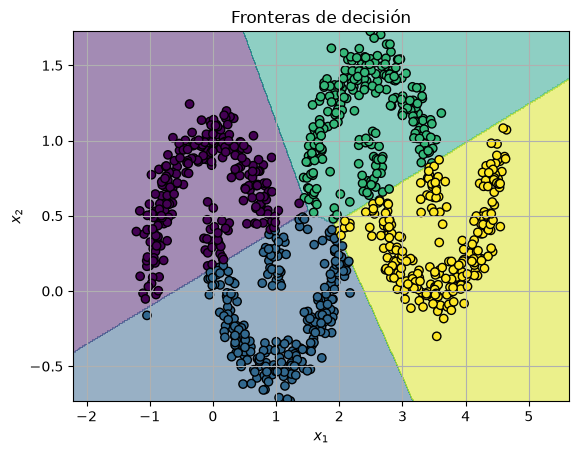

In [12]:
W1, b1 = params   

y_pred = predict(X, W1, b1)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
h = 0.01

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

grid = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = torch.FloatTensor(grid)

preds = predict(grid_tensor, W1, b1).detach().numpy()
Z = preds.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.5, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=y_pred.numpy(),
            cmap='viridis', edgecolors='k')

plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.grid(True)

plt.ylim(X[:,1].min(), X[:,1].max())
plt.title('Fronteras de decisión')
plt.show()


## Multilayer Perceptron (MLP)

Podemos mejorar considerablemente la situación utilizando un **perceptrón multicapa**. Por el momento, vamos a codificar un **perceptrón de 2 capas**.

En esta arquitectura, la primera capa oculta se obtiene mediante una combinación lineal de la capa de entrada, y cada neurona es activada por una función de activación $\sigma$ que tomaremos como $\mathrm{ReLU}(x)$.
La salida se obtiene de nuevo mediante una combinación lineal de la capa oculta.
A continuación pasamos la salida por una activación softmax para obtener la probabilidad de cada clase:
$$
\boldsymbol{H} = \sigma\left(\boldsymbol{X} \boldsymbol{W}^{(1)} + \boldsymbol{b}^{(1)}\right), $$
$$
\boldsymbol{O}  = \text{softmax}\left(\boldsymbol{H}\boldsymbol{W}^{(2)} + \boldsymbol{b}^{(2)}\right).
$$



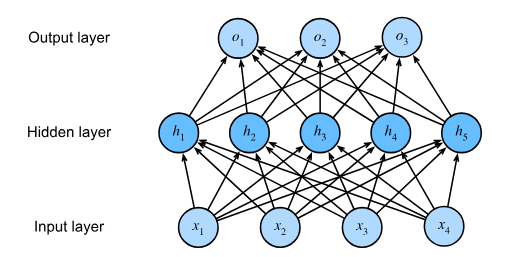

Como en el perceptrón multiclase, vamos a definir una clase **MLP**.
Comenzamos definiendo la función `init` para inicializar aleatoriamente las matrices de acoplamiento $W^{(1)}$ y $W^{(2)}$, y para poner a cero los dos sesgos $b^{(1)}$ y $b^{(2)}$.

In [13]:
import torch
import torch.nn as nn

def init_mlp(num_inputs, num_outputs, num_hiddens):
    W1 = nn.Parameter(torch.randn(num_inputs, num_hiddens) * 0.1)
    b1 = nn.Parameter(torch.zeros(num_hiddens))
    W2 = nn.Parameter(torch.randn(num_hiddens, num_outputs) * 0.1)
    b2 = nn.Parameter(torch.zeros(num_outputs))
    return [W1, b1, W2, b2]


def forward(X, W1, b1, W2, b2):
    H = torch.relu(torch.matmul(X, W1) + b1)
    O = torch.matmul(H, W2) + b2
    return torch.softmax(O, dim=1)


def predict(X, W1, b1, W2, b2):
    H = torch.relu(torch.matmul(X, W1) + b1)
    O = torch.matmul(H, W2) + b2
    return torch.argmax(O, dim=1)


def cross_entropy_loss(X, labels, params):
    W1, b1, W2, b2 = params
    y_pred = forward(X, W1, b1, W2, b2)
    return -torch.sum(labels * torch.log(y_pred + 1e-8)) / X.size(0)


def errors(X, labels, params):
    W1, b1, W2, b2 = params
    class_pred = predict(X, W1, b1, W2, b2)
    class_original = torch.argmax(labels, dim=1)
    return torch.sum(class_pred != class_original) / X.shape[0]


def param_update(params, lr):
    with torch.no_grad():
        for p in params:
            if p.grad is not None:
                p.data -= lr * p.grad


def train_step(X, labels, params, lr):

    # Paso forward + pérdida
    loss = cross_entropy_loss(X, labels, params)

    # Poner gradientes a cero
    for p in params:
        p.grad = None

    # Backpropagation
    loss.backward()

    # Actualizar parámetros
    param_update(params, lr)

    # Calcular errores
    err = errors(X, labels, params)

    return loss.item(), err.item()

In [14]:
params = init_mlp(num_inputs=X.shape[1],
                  num_outputs=num_classes,
                  num_hiddens=100)

In [15]:
# Hiperparámetros de entrenamiento
learning_rate = 1
epochs = 10000

for epoch in range(epochs):

    loss, err = train_step(X, y, params, learning_rate)

    #print(f"Epoch {epoch+1}, Loss: {loss}, Error: {err}")

    if err == 0:
        break

Epoch 181, Loss: 0.29956987500190735, Error: 0.11900000274181366
Epoch 182, Loss: 0.2882066071033478, Error: 0.1289999932050705
Epoch 183, Loss: 0.2978205382823944, Error: 0.11800000071525574
Epoch 184, Loss: 0.2864868640899658, Error: 0.125
Epoch 185, Loss: 0.29560697078704834, Error: 0.11699999868869781
Epoch 186, Loss: 0.28459692001342773, Error: 0.12200000137090683
Epoch 187, Loss: 0.2933002710342407, Error: 0.11599999666213989
Epoch 188, Loss: 0.2828325927257538, Error: 0.12099999934434891
Epoch 189, Loss: 0.2911991477012634, Error: 0.11500000208616257
Epoch 190, Loss: 0.28151553869247437, Error: 0.12099999934434891
Epoch 191, Loss: 0.2901901304721832, Error: 0.1120000034570694
Epoch 192, Loss: 0.28078070282936096, Error: 0.11999999731779099
Epoch 193, Loss: 0.28988364338874817, Error: 0.11100000143051147
Epoch 194, Loss: 0.2803913652896881, Error: 0.11900000274181366
Epoch 195, Loss: 0.2897512912750244, Error: 0.11400000005960464
Epoch 196, Loss: 0.2801068425178528, Error: 0.1209

Epoch 395, Loss: 0.21247263252735138, Error: 0.0860000029206276
Epoch 396, Loss: 0.20330198109149933, Error: 0.07900000363588333
Epoch 397, Loss: 0.21219179034233093, Error: 0.08699999749660492
Epoch 398, Loss: 0.20366714894771576, Error: 0.07900000363588333
Epoch 399, Loss: 0.21325401961803436, Error: 0.08699999749660492
Epoch 400, Loss: 0.20333054661750793, Error: 0.07900000363588333
Epoch 401, Loss: 0.2121385633945465, Error: 0.0860000029206276
Epoch 402, Loss: 0.20249222218990326, Error: 0.07699999958276749
Epoch 403, Loss: 0.21174895763397217, Error: 0.0860000029206276
Epoch 404, Loss: 0.20132964849472046, Error: 0.07699999958276749
Epoch 405, Loss: 0.209471195936203, Error: 0.08399999886751175
Epoch 406, Loss: 0.19998030364513397, Error: 0.07800000160932541
Epoch 407, Loss: 0.2087315320968628, Error: 0.08299999684095383
Epoch 408, Loss: 0.19937783479690552, Error: 0.07800000160932541
Epoch 409, Loss: 0.20742008090019226, Error: 0.08299999684095383
Epoch 410, Loss: 0.1991152912378

Epoch 635, Loss: 0.16123957931995392, Error: 0.06400000303983688
Epoch 636, Loss: 0.15402445197105408, Error: 0.06400000303983688
Epoch 637, Loss: 0.16097590327262878, Error: 0.06199999898672104
Epoch 638, Loss: 0.15359891951084137, Error: 0.06499999761581421
Epoch 639, Loss: 0.16008444130420685, Error: 0.06400000303983688
Epoch 640, Loss: 0.1535942405462265, Error: 0.06499999761581421
Epoch 641, Loss: 0.1609167754650116, Error: 0.06300000101327896
Epoch 642, Loss: 0.15338146686553955, Error: 0.06499999761581421
Epoch 643, Loss: 0.1598031371831894, Error: 0.06300000101327896
Epoch 644, Loss: 0.15299300849437714, Error: 0.06499999761581421
Epoch 645, Loss: 0.1603114902973175, Error: 0.06199999898672104
Epoch 646, Loss: 0.15285716950893402, Error: 0.06499999761581421
Epoch 647, Loss: 0.1596413254737854, Error: 0.06300000101327896
Epoch 648, Loss: 0.15267035365104675, Error: 0.06499999761581421
Epoch 649, Loss: 0.15964627265930176, Error: 0.06199999898672104
Epoch 650, Loss: 0.15237088501

Epoch 873, Loss: 0.13776621222496033, Error: 0.04699999839067459
Epoch 874, Loss: 0.1316596418619156, Error: 0.0560000017285347
Epoch 875, Loss: 0.1354421228170395, Error: 0.04600000008940697
Epoch 876, Loss: 0.1274309903383255, Error: 0.05299999937415123
Epoch 877, Loss: 0.13228586316108704, Error: 0.04600000008940697
Epoch 878, Loss: 0.12985537946224213, Error: 0.0560000017285347
Epoch 879, Loss: 0.13596881926059723, Error: 0.04899999871850014
Epoch 880, Loss: 0.13388372957706451, Error: 0.05400000140070915
Epoch 881, Loss: 0.13640685379505157, Error: 0.04699999839067459
Epoch 882, Loss: 0.1281539797782898, Error: 0.05299999937415123
Epoch 883, Loss: 0.13171076774597168, Error: 0.04500000178813934
Epoch 884, Loss: 0.1262853890657425, Error: 0.05299999937415123
Epoch 885, Loss: 0.13188935816287994, Error: 0.04600000008940697
Epoch 886, Loss: 0.1295912116765976, Error: 0.0560000017285347
Epoch 887, Loss: 0.1360909640789032, Error: 0.04899999871850014
Epoch 888, Loss: 0.1327098459005355

Epoch 1103, Loss: 0.11746098846197128, Error: 0.04399999976158142
Epoch 1104, Loss: 0.11199431121349335, Error: 0.04800000041723251
Epoch 1105, Loss: 0.11381886899471283, Error: 0.03999999910593033
Epoch 1106, Loss: 0.10938318818807602, Error: 0.0430000014603138
Epoch 1107, Loss: 0.1096077710390091, Error: 0.03500000014901161
Epoch 1108, Loss: 0.10233674198389053, Error: 0.04399999976158142
Epoch 1109, Loss: 0.10688403993844986, Error: 0.04100000113248825
Epoch 1110, Loss: 0.10976473242044449, Error: 0.04699999839067459
Epoch 1111, Loss: 0.11243443936109543, Error: 0.035999998450279236
Epoch 1112, Loss: 0.104837566614151, Error: 0.04600000008940697
Epoch 1113, Loss: 0.11167444288730621, Error: 0.04399999976158142
Epoch 1114, Loss: 0.1139463484287262, Error: 0.052000001072883606
Epoch 1115, Loss: 0.11898721754550934, Error: 0.03700000047683716
Epoch 1116, Loss: 0.1074007898569107, Error: 0.04899999871850014
Epoch 1117, Loss: 0.11332634836435318, Error: 0.04399999976158142
Epoch 1118, Lo

...

Epoch 2740, Loss: 0.008774308487772942, Error: 0.0010000000474974513
Epoch 2741, Loss: 0.008768360130488873, Error: 0.0010000000474974513
Epoch 2742, Loss: 0.008762197569012642, Error: 0.0010000000474974513
Epoch 2743, Loss: 0.008755951188504696, Error: 0.0010000000474974513
Epoch 2744, Loss: 0.008749935775995255, Error: 0.0010000000474974513
Epoch 2745, Loss: 0.008744163438677788, Error: 0.0010000000474974513
Epoch 2746, Loss: 0.008737856522202492, Error: 0.0010000000474974513
Epoch 2747, Loss: 0.008731784299015999, Error: 0.0010000000474974513
Epoch 2748, Loss: 0.008725984022021294, Error: 0.0010000000474974513
Epoch 2749, Loss: 0.008720013312995434, Error: 0.0010000000474974513
Epoch 2750, Loss: 0.008713803254067898, Error: 0.0010000000474974513
Epoch 2751, Loss: 0.00870747771114111, Error: 0.0010000000474974513
Epoch 2752, Loss: 0.008701834827661514, Error: 0.0010000000474974513
Epoch 2753, Loss: 0.008695593103766441, Error: 0.0010000000474974513
Epoch 2754, Loss: 0.008689659647643

Epoch 2969, Loss: 0.00758709479123354, Error: 0.0010000000474974513
Epoch 2970, Loss: 0.007563446648418903, Error: 0.0010000000474974513
Epoch 2971, Loss: 0.007556256838142872, Error: 0.0010000000474974513
Epoch 2972, Loss: 0.007550426293164492, Error: 0.0010000000474974513
Epoch 2973, Loss: 0.0075455703772604465, Error: 0.0010000000474974513
Epoch 2974, Loss: 0.007540241349488497, Error: 0.0010000000474974513
Epoch 2975, Loss: 0.007535367738455534, Error: 0.0010000000474974513
Epoch 2976, Loss: 0.007531576324254274, Error: 0.0010000000474974513
Epoch 2977, Loss: 0.007550485897809267, Error: 0.0010000000474974513
Epoch 2978, Loss: 0.007533285301178694, Error: 0.0010000000474974513
Epoch 2979, Loss: 0.0075343637727200985, Error: 0.0010000000474974513
Epoch 2980, Loss: 0.007517300546169281, Error: 0.0010000000474974513
Epoch 2981, Loss: 0.007510504685342312, Error: 0.0010000000474974513
Epoch 2982, Loss: 0.007505202665925026, Error: 0.0010000000474974513
Epoch 2983, Loss: 0.0075002070516

Epoch 3133, Loss: 0.006911796052008867, Error: 0.0010000000474974513
Epoch 3134, Loss: 0.006920249667018652, Error: 0.0010000000474974513
Epoch 3135, Loss: 0.006898608524352312, Error: 0.0010000000474974513
Epoch 3136, Loss: 0.006892560049891472, Error: 0.0010000000474974513
Epoch 3137, Loss: 0.006888085976243019, Error: 0.0010000000474974513
Epoch 3138, Loss: 0.006888571660965681, Error: 0.0010000000474974513
Epoch 3139, Loss: 0.006900652311742306, Error: 0.0010000000474974513
Epoch 3140, Loss: 0.006880209781229496, Error: 0.0010000000474974513
Epoch 3141, Loss: 0.00687413290143013, Error: 0.0010000000474974513
Epoch 3142, Loss: 0.006869158707559109, Error: 0.0010000000474974513
Epoch 3143, Loss: 0.006872544996440411, Error: 0.0010000000474974513
Epoch 3144, Loss: 0.006881827488541603, Error: 0.0010000000474974513
Epoch 3145, Loss: 0.006861231289803982, Error: 0.0010000000474974513
Epoch 3146, Loss: 0.006855402607470751, Error: 0.0010000000474974513
Epoch 3147, Loss: 0.006857665255665

Epoch 3301, Loss: 0.006346510257571936, Error: 0.0010000000474974513
Epoch 3302, Loss: 0.006350074894726276, Error: 0.0010000000474974513
Epoch 3303, Loss: 0.006359283812344074, Error: 0.0010000000474974513
Epoch 3304, Loss: 0.006340139079838991, Error: 0.0010000000474974513
Epoch 3305, Loss: 0.006334307603538036, Error: 0.0010000000474974513
Epoch 3306, Loss: 0.006351622752845287, Error: 0.0010000000474974513
Epoch 3307, Loss: 0.006332756485790014, Error: 0.0010000000474974513
Epoch 3308, Loss: 0.006325278431177139, Error: 0.0010000000474974513
Epoch 3309, Loss: 0.006327736657112837, Error: 0.0010000000474974513
Epoch 3310, Loss: 0.0063378759659826756, Error: 0.0010000000474974513
Epoch 3311, Loss: 0.006318830419331789, Error: 0.0010000000474974513
Epoch 3312, Loss: 0.00631306879222393, Error: 0.0010000000474974513
Epoch 3313, Loss: 0.006330583710223436, Error: 0.0010000000474974513
Epoch 3314, Loss: 0.006310750730335712, Error: 0.0010000000474974513
Epoch 3315, Loss: 0.00630392925813

Epoch 3468, Loss: 0.0058890776708722115, Error: 0.0010000000474974513
Epoch 3469, Loss: 0.005875025410205126, Error: 0.0010000000474974513
Epoch 3470, Loss: 0.005906630307435989, Error: 0.0010000000474974513
Epoch 3471, Loss: 0.005870699416846037, Error: 0.0010000000474974513
Epoch 3472, Loss: 0.005869224667549133, Error: 0.0010000000474974513
Epoch 3473, Loss: 0.005877866875380278, Error: 0.0010000000474974513
Epoch 3474, Loss: 0.005862085148692131, Error: 0.0010000000474974513
Epoch 3475, Loss: 0.005861383397132158, Error: 0.0010000000474974513
Epoch 3476, Loss: 0.005869417451322079, Error: 0.0010000000474974513
Epoch 3477, Loss: 0.005853635724633932, Error: 0.0010000000474974513
Epoch 3478, Loss: 0.005854370538145304, Error: 0.0010000000474974513
Epoch 3479, Loss: 0.0058609978295862675, Error: 0.0010000000474974513
Epoch 3480, Loss: 0.005845427047461271, Error: 0.0010000000474974513
Epoch 3481, Loss: 0.005862839054316282, Error: 0.0010000000474974513
Epoch 3482, Loss: 0.005843034014

C:\Users\elena\AppData\Local\Temp\ipykernel_18168\3237838210.py:12: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
C:\Users\elena\AppData\Local\Temp\ipykernel_18168\3237838210.py:13: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.arange(y_min, y_max, h))


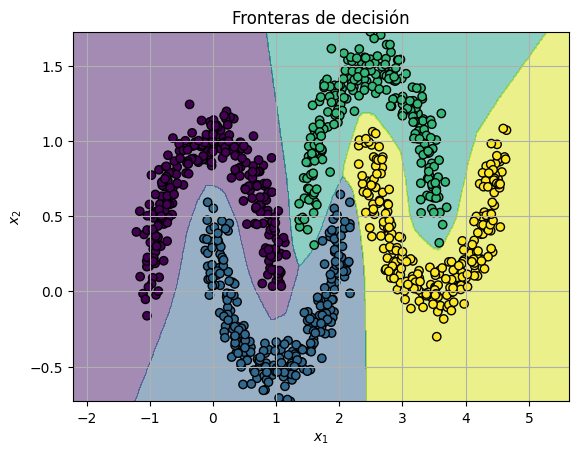

In [17]:
# Desempaquetar parámetros del modelo funcional
W1, b1, W2, b2 = params

# Predicciones sobre los datos reales
y_pred = predict(X, W1, b1, W2, b2)

# Rango del grid
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
h = 0.01

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Construcción del grid
grid = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = torch.FloatTensor(grid)

# Predicciones del modelo sobre el grid
preds = predict(grid_tensor, W1, b1, W2, b2).detach().numpy()

# Reshape para el contourf
Z = preds.reshape(xx.shape)

# Plot de las fronteras de decisión
plt.contourf(xx, yy, Z, alpha=0.5, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1], c=y_pred.numpy(),
            cmap='viridis', edgecolors='k')

plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.grid(True)
plt.ylim(X[:,1].min(), X[:,1].max())
plt.title('Fronteras de decisión')
plt.show()


## Varias capas

Vamos a considerar ahora **3 capas ocultas** en nuestro perceptrón multicapa.
Podemos simplificar la definición de los parámetros del modelo utilizando la función `nn.Linear`, que construye una transformación lineal entre una entrada y una dimensión de salida.

Como este modelo tiene muchos más parámetros y, por tanto, requiere más tiempo de entrenamiento, también implementaremos el **descenso de gradiente estocástico**, en el cual el gradiente se calcula utilizando solo un pequeño conjunto de muestras incluidas en un **minibatch** (esto ya lo implementamos en la regresión lineal).
En este esquema, una época termina cuando todas las entradas del conjunto de entrenamiento han sido procesadas.




In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F


def init_M3LP(num_inputs, num_outputs, num_hiddens):

    fc1 = nn.Linear(num_inputs, num_hiddens)
    fc2 = nn.Linear(num_hiddens, num_hiddens)
    fc3 = nn.Linear(num_hiddens, int(0.5 * num_hiddens))
    fcout = nn.Linear(int(0.5 * num_hiddens), num_outputs)

    params = (
        list(fc1.parameters()) +
        list(fc2.parameters()) +
        list(fc3.parameters()) +
        list(fcout.parameters())
    )

    return fc1, fc2, fc3, fcout, params


def forward_M3LP(X, fc1, fc2, fc3, fcout):
    H1 = F.relu(fc1(X))
    H2 = F.relu(fc2(H1))
    H3 = F.relu(fc3(H2))
    O  = fcout(H3)
    return torch.softmax(O, dim=1)


def predict_M3LP(X, fc1, fc2, fc3, fcout):
    H1 = F.relu(fc1(X))
    H2 = F.relu(fc2(H1))
    H3 = F.relu(fc3(H2))
    O  = fcout(H3)
    return torch.argmax(O, dim=1)


def cross_entropy_loss_M3LP(X, labels, fc1, fc2, fc3, fcout):
    y_pred = forward_M3LP(X, fc1, fc2, fc3, fcout)
    return -torch.sum(labels * torch.log(y_pred + 1e-8)) / X.size(0)


def errors_M3LP(X, labels, fc1, fc2, fc3, fcout):
    class_pred = predict_M3LP(X, fc1, fc2, fc3, fcout)
    class_original = torch.argmax(labels, dim=1)
    return torch.sum(class_pred != class_original) / X.shape[0]


def param_update(params, lr):
    with torch.no_grad():
        for p in params:
            if p.grad is not None:
                p.data -= lr * p.grad


def train_step_M3LP(X, labels, fc1, fc2, fc3, fcout, params, lr):

    loss = cross_entropy_loss_M3LP(X, labels, fc1, fc2, fc3, fcout)

    for p in params:
        p.grad = None

    loss.backward()

    param_update(params, lr)

    err = errors_M3LP(X, labels, fc1, fc2, fc3, fcout)

    return loss.item(), err.item()


def train_SGD_step_M3LP(X, labels, fc1, fc2, fc3, fcout, params, lr, minibatch=48):

    N = X.shape[0]

    for ibatch in range(N // minibatch):

        X_mb = X[ibatch*minibatch:(ibatch+1)*minibatch]
        y_mb = labels[ibatch*minibatch:(ibatch+1)*minibatch]

        loss = cross_entropy_loss_M3LP(X_mb, y_mb, fc1, fc2, fc3, fcout)

        for p in params:
            p.grad = None

        loss.backward()

        param_update(params, lr)

    err = errors_M3LP(X, labels, fc1, fc2, fc3, fcout)

    return loss.item(), err.item()

Lanzamos un nuevo entrenamiento con SGD

In [18]:
fc1, fc2, fc3, fcout, params = init_M3LP(
    num_inputs=X.shape[1],
    num_outputs=num_classes,
    num_hiddens=100
)

learning_rate = 0.1
epochs = 200

for epoch in range(epochs):
    loss, err = train_SGD_step_M3LP(X, y, fc1, fc2, fc3, fcout, params, learning_rate)
    #print(f"Epoch {epoch+1}, Loss: {loss:.4f}, Error: {err:.4f}")
    if err == 0:
        break



Epoch 128, Loss: 0.0032852161675691605, Error: 0.007000000216066837
Epoch 129, Loss: 0.003294731257483363, Error: 0.004999999888241291
Epoch 130, Loss: 0.003027198603376746, Error: 0.004999999888241291
Epoch 131, Loss: 0.0030980471055954695, Error: 0.004999999888241291
Epoch 132, Loss: 0.003085297765210271, Error: 0.004000000189989805
Epoch 133, Loss: 0.002787816571071744, Error: 0.004000000189989805
Epoch 134, Loss: 0.002885539084672928, Error: 0.003000000026077032
Epoch 135, Loss: 0.0028604939579963684, Error: 0.003000000026077032
Epoch 136, Loss: 0.0026418203487992287, Error: 0.003000000026077032
Epoch 137, Loss: 0.002695583738386631, Error: 0.003000000026077032
Epoch 138, Loss: 0.0026951918844133615, Error: 0.003000000026077032
Epoch 139, Loss: 0.0023644447792321444, Error: 0.003000000026077032
Epoch 140, Loss: 0.0025783702731132507, Error: 0.003000000026077032
Epoch 141, Loss: 0.002403881633654237, Error: 0.003000000026077032
Epoch 142, Loss: 0.0024519602302461863, Error: 0.003000

Muestra las fronteras de decisión obtenidas con cada modelo.
¿Observas alguna diferencia con respecto a los casos anteriores?

C:\Users\elena\AppData\Local\Temp\ipykernel_400\119120585.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
C:\Users\elena\AppData\Local\Temp\ipykernel_400\119120585.py:8: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.arange(y_min, y_max, h))


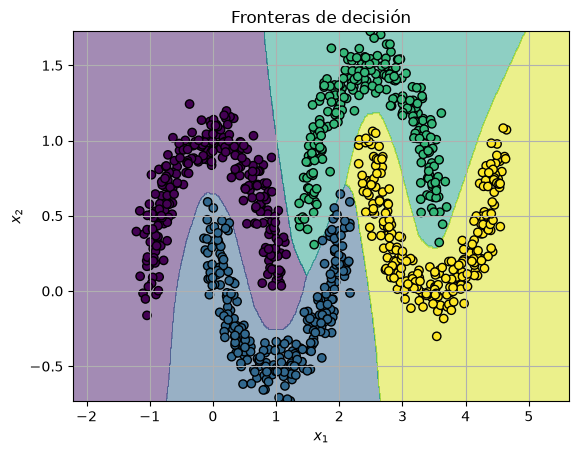

In [19]:
y_pred = predict_M3LP(X, fc1, fc2, fc3, fcout)

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
h = 0.01

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

grid = np.c_[xx.ravel(), yy.ravel()]
grid_tensor = torch.FloatTensor(grid)

preds = predict_M3LP(grid_tensor, fc1, fc2, fc3, fcout).detach().numpy()

Z = preds.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.5, cmap='viridis')
plt.scatter(X[:, 0], X[:, 1],
            c=y_pred.numpy(),
            cmap='viridis',
            edgecolors='k')

plt.xlabel(r'$x_1$')
plt.ylabel(r'$x_2$')
plt.grid(True)

plt.ylim(X[:,1].min(), X[:,1].max())
plt.title('Fronteras de decisión')
plt.show()


Se puede observar que las fronteras del perceptron de 3 capas son más precisas que las del perceptron de 2 capas y ambas son mucho más claras que las del perceptron multiclase cuando se aplican a datos linealmente no separables